In [1]:
!pip install liac-arff pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.2 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11768 sha256=434a3d7da88de7f4c4f07c8cf2f25d7b6765e47d1289c7afcf21221e6a1152d0
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [2]:
# === KC3 Step 1A: Load and Inspect Label Column ===
from scipy.io import arff
import pandas as pd

kc3_path = "/content/KC3.arff"
data, meta = arff.loadarff(kc3_path)
df_kc3 = pd.DataFrame(data)

# Decode any byte strings
for col in df_kc3.columns:
    if df_kc3[col].dtype == object:
        df_kc3[col] = df_kc3[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print("Loaded KC3 shape:", df_kc3.shape)
print("Columns:", df_kc3.columns.tolist())

# Check last few rows and unique values in label
print("\nUnique values in 'Defective' column:")
print(df_kc3['Defective'].unique())


Loaded KC3 shape: (194, 40)
Columns: ['LOC_BLANK', 'BRANCH_COUNT', 'CALL_PAIRS', 'LOC_CODE_AND_COMMENT', 'LOC_COMMENTS', 'CONDITION_COUNT', 'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY', 'DESIGN_COMPLEXITY', 'DESIGN_DENSITY', 'EDGE_COUNT', 'ESSENTIAL_COMPLEXITY', 'ESSENTIAL_DENSITY', 'LOC_EXECUTABLE', 'PARAMETER_COUNT', 'GLOBAL_DATA_COMPLEXITY', 'GLOBAL_DATA_DENSITY', 'HALSTEAD_CONTENT', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST', 'HALSTEAD_LENGTH', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME', 'HALSTEAD_VOLUME', 'MAINTENANCE_SEVERITY', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT', 'NODE_COUNT', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'NUM_OPERANDS', 'NUM_OPERATORS', 'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'NUMBER_OF_LINES', 'PERCENT_COMMENTS', 'LOC_TOTAL', 'Defective']

Unique values in 'Defective' column:
['Y' 'N']


In [3]:
# === KC3 Step 1B: Clean and Encode Target Column ===
import numpy as np

# Convert all to lowercase string
df_kc3['Defective'] = df_kc3['Defective'].astype(str).str.strip().str.lower()

# Replace common values with 1 or 0
df_kc3['Defective'] = df_kc3['Defective'].replace({
    'y': 1, 'yes': 1, 'true': 1, '1': 1,
    'n': 0, 'no': 0, 'false': 0, '0': 0,
    '?': np.nan, 'none': np.nan, 'nan': np.nan
})

# Drop missing targets if any
df_kc3 = df_kc3.dropna(subset=['Defective'])
df_kc3['Defective'] = df_kc3['Defective'].astype(int)

# Verify cleaning
print("\nLabel column cleaned successfully.")
print(df_kc3['Defective'].value_counts())



Label column cleaned successfully.
Defective
0    158
1     36
Name: count, dtype: int64


/tmp/ipython-input-3724626040.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_kc3['Defective'] = df_kc3['Defective'].replace({



=== Dataset Summary ===
                                 count          mean           std     min  \
LOC_BLANK                        194.0      4.809278      5.785431    0.00   
BRANCH_COUNT                     194.0     10.835052     10.075035    3.00   
CALL_PAIRS                       194.0      9.515464      7.841187    1.00   
LOC_CODE_AND_COMMENT             194.0      0.231959      0.847312    0.00   
LOC_COMMENTS                     194.0      2.463918      4.788938    0.00   
CONDITION_COUNT                  194.0     14.113402     14.259168    4.00   
CYCLOMATIC_COMPLEXITY            194.0      6.350515      5.623860    2.00   
CYCLOMATIC_DENSITY               194.0      0.230619      0.086693    0.09   
DECISION_COUNT                   194.0      6.628866      6.581210    2.00   
DECISION_DENSITY                 194.0      2.127010      0.320942    2.00   
DESIGN_COMPLEXITY                194.0      5.453608      4.809362    1.00   
DESIGN_DENSITY                   194.0 

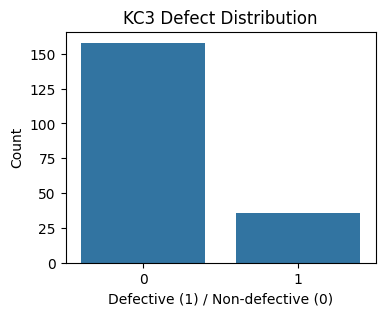

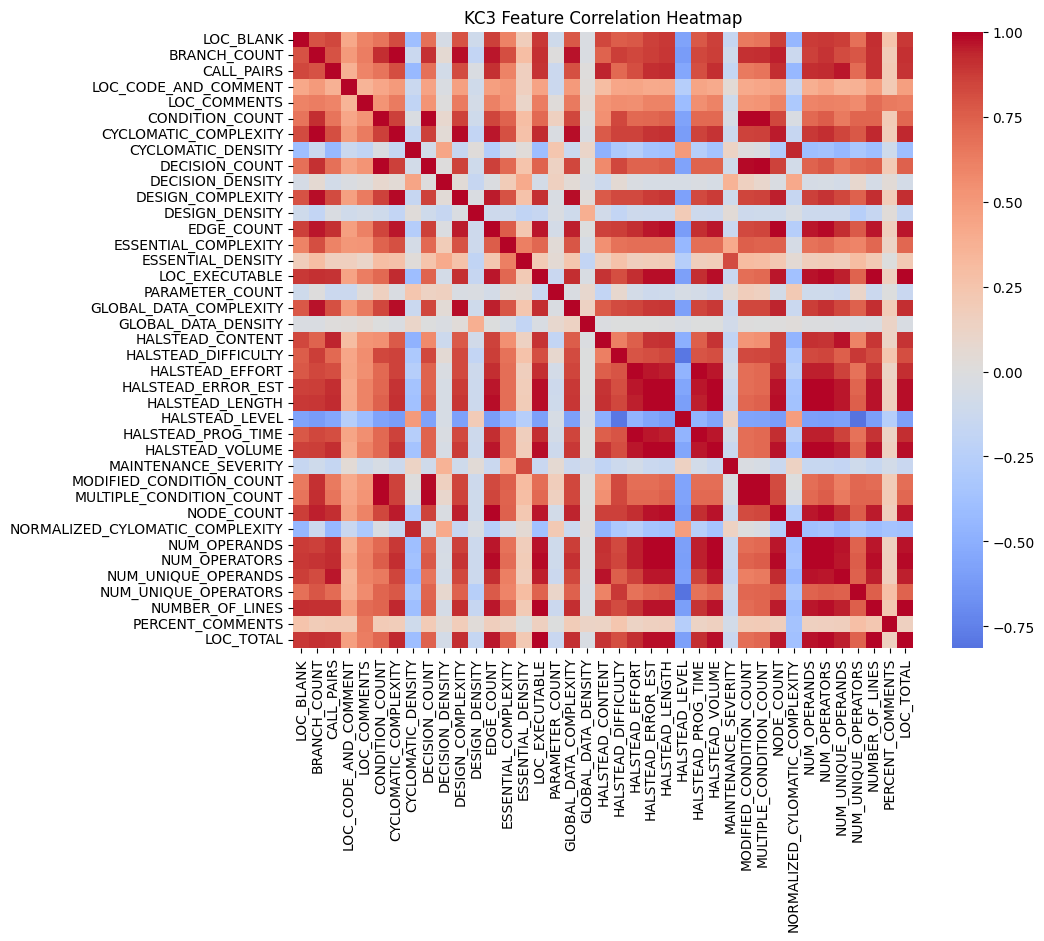

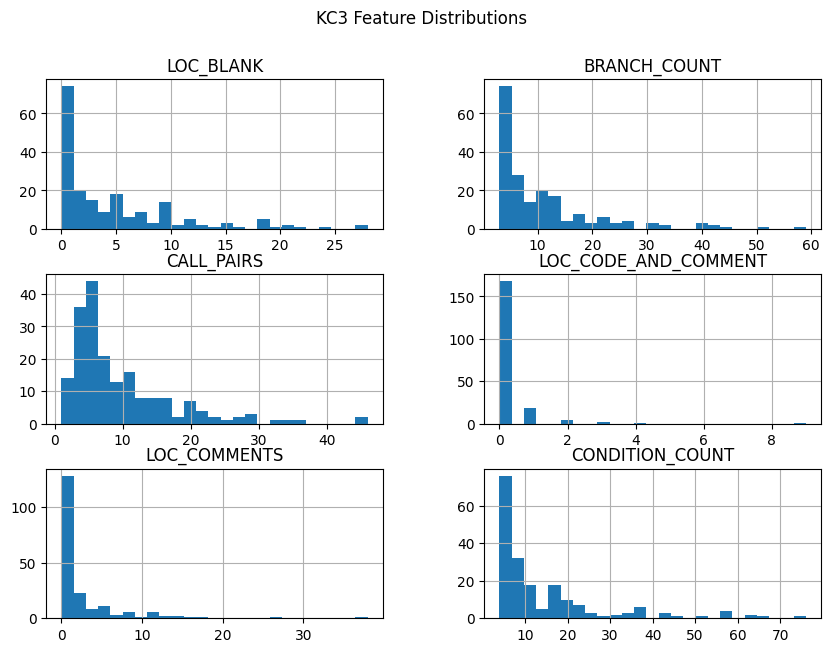

In [4]:
# === KC3 Step 1C: EDA ===
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y = df_kc3['Defective']
X = df_kc3.drop(columns=['Defective'])

print("\n=== Dataset Summary ===")
print(df_kc3.describe().T)

print("\nMissing values:\n", df_kc3.isnull().sum().sum())

# Class distribution
plt.figure(figsize=(4,3))
sns.countplot(x=y)
plt.title("KC3 Defect Distribution")
plt.xlabel("Defective (1) / Non-defective (0)")
plt.ylabel("Count")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title("KC3 Feature Correlation Heatmap")
plt.show()

# Distribution plots for first few numeric features
num_cols = X.select_dtypes(include=[np.number]).columns[:6]
df_kc3[num_cols].hist(bins=25, figsize=(10,7))
plt.suptitle("KC3 Feature Distributions")
plt.show()


After variance threshold: (194, 39)
Dropping highly correlated features: ['CONDITION_COUNT', 'CYCLOMATIC_COMPLEXITY', 'DECISION_COUNT', 'DESIGN_COMPLEXITY', 'EDGE_COUNT', 'LOC_EXECUTABLE', 'GLOBAL_DATA_COMPLEXITY', 'HALSTEAD_CONTENT', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST', 'HALSTEAD_LENGTH', 'HALSTEAD_PROG_TIME', 'HALSTEAD_VOLUME', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT', 'NODE_COUNT', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'NUM_OPERANDS', 'NUM_OPERATORS', 'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'NUMBER_OF_LINES', 'LOC_TOTAL']
After correlation filter: (194, 15)


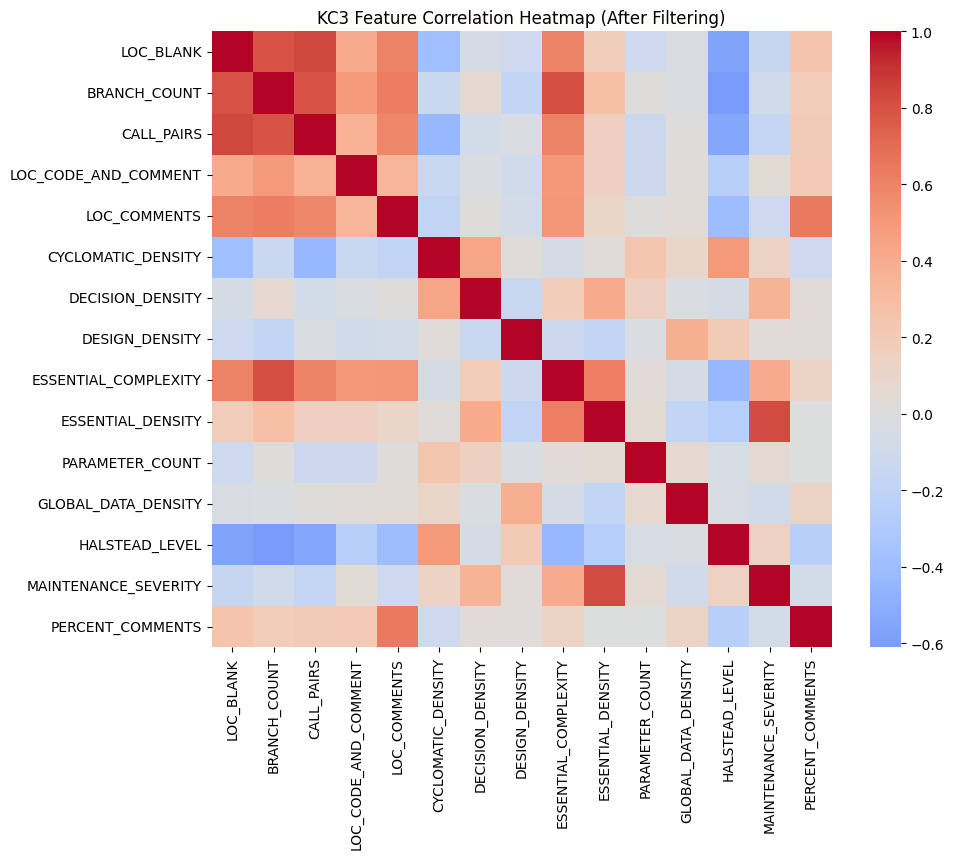


Top 10 features by mutual information:
 PERCENT_COMMENTS        0.084424
LOC_COMMENTS            0.069953
LOC_CODE_AND_COMMENT    0.067092
MAINTENANCE_SEVERITY    0.043883
BRANCH_COUNT            0.036307
LOC_BLANK               0.026697
GLOBAL_DATA_DENSITY     0.023779
PARAMETER_COUNT         0.022035
HALSTEAD_LEVEL          0.012828
ESSENTIAL_DENSITY       0.012431
dtype: float64


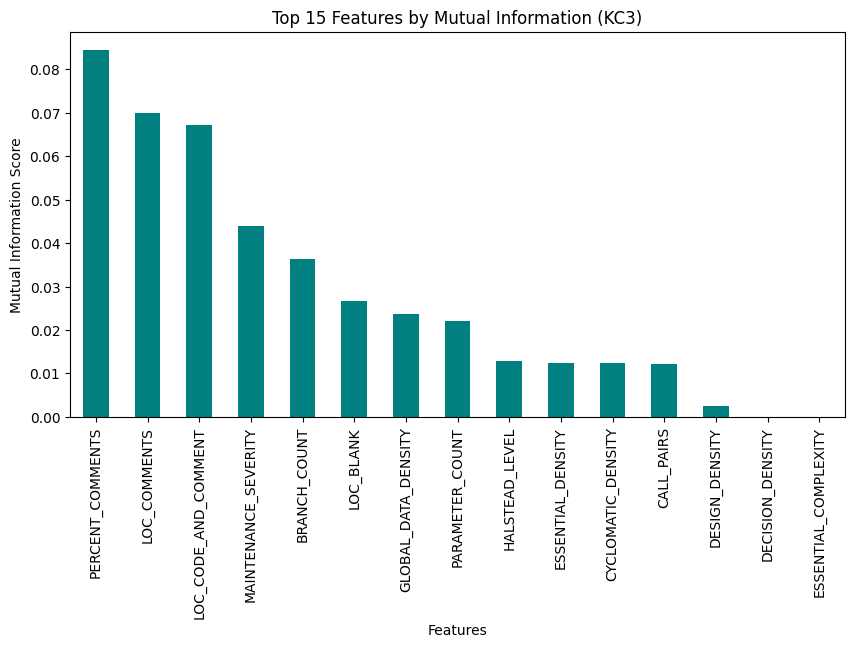


Selected features via RFE: ['LOC_BLANK', 'BRANCH_COUNT', 'CALL_PAIRS', 'LOC_CODE_AND_COMMENT', 'LOC_COMMENTS', 'CYCLOMATIC_DENSITY', 'DESIGN_DENSITY', 'PARAMETER_COUNT', 'GLOBAL_DATA_DENSITY', 'HALSTEAD_LEVEL', 'MAINTENANCE_SEVERITY', 'PERCENT_COMMENTS']
Final X_sel shape: (194, 12)

Before SMOTE class distribution: [158  36]
After SMOTE class distribution: [158 158]
Resampled shape: (316, 12)


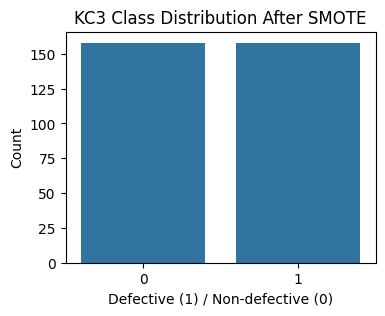


=== Step 2 Completed ===
You can now use X_res, y_res for model training in Step 3 (Ensemble Learning).


In [5]:
# === KC3 Step 2: Feature Selection + Correlation Filter + SMOTE ===
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = df_kc3.drop(columns=['Defective'])
y = df_kc3['Defective']

# 1) Variance threshold — remove near-constant features
var_thresh = VarianceThreshold(threshold=0.0)
X_var = pd.DataFrame(var_thresh.fit_transform(X), columns=X.columns[var_thresh.get_support()])
print(f"After variance threshold: {X_var.shape}")

# 2) Correlation filtering — drop highly correlated (>0.85) features
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X_corr = X_var.drop(columns=to_drop)
print(f"Dropping highly correlated features: {to_drop}")
print(f"After correlation filter: {X_corr.shape}")

# --- Visualize correlation heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(X_corr.corr(), cmap='coolwarm', center=0)
plt.title("KC3 Feature Correlation Heatmap (After Filtering)")
plt.show()

# 3) Mutual Information — rank features by predictive power
mi_scores = mutual_info_classif(X_corr, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_corr.columns).sort_values(ascending=False)
print("\nTop 10 features by mutual information:\n", mi_series.head(10))

# --- Bar chart for MI importance ---
plt.figure(figsize=(10,5))
mi_series.head(15).plot(kind='bar', color='teal')
plt.title("Top 15 Features by Mutual Information (KC3)")
plt.ylabel("Mutual Information Score")
plt.xlabel("Features")
plt.show()

# 4) Recursive Feature Elimination (RFE) using Random Forest
rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=min(12, X_corr.shape[1]))
rfe.fit(X_corr, y)
selected_features = X_corr.columns[rfe.support_].tolist()
print("\nSelected features via RFE:", selected_features)

X_sel = X_corr[selected_features]
print(f"Final X_sel shape: {X_sel.shape}")

# 5) Handle class imbalance with SMOTE
print("\nBefore SMOTE class distribution:", np.bincount(y))
sm = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=3)
X_res, y_res = sm.fit_resample(X_sel, y)
print("After SMOTE class distribution:", np.bincount(y_res))
print(f"Resampled shape: {X_res.shape}")

# --- Visualize class balance after SMOTE ---
plt.figure(figsize=(4,3))
sns.countplot(x=y_res)
plt.title("KC3 Class Distribution After SMOTE")
plt.xlabel("Defective (1) / Non-defective (0)")
plt.ylabel("Count")
plt.show()

print("\n=== Step 2 Completed ===")
print("You can now use X_res, y_res for model training in Step 3 (Ensemble Learning).")


Train shape: (252, 12) Test shape: (64, 12)
RF best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300} CV AUC: 0.9405661538461538 time(s): 5.61
ET best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300} CV AUC: 0.9550092307692306 time(s): 3.51
XGB done time(s): 0.02
[LightGBM] [Info] Number of positive: 126, number of negative: 126
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:20:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Stacking trained in (s): 2.46

--- RandomForest_Tuned ---
AUC: 0.9814  PR-AUC: 0.9833  F1: 0.9231  Precision: 0.9091  Recall: 0.9375  MCC: 0.8442  Acc: 0.9219  LogLoss: 0.2408
Confusion matrix:
 [[29  3]
 [ 2 30]]
Classification report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92        32
           1       0.91      0.94      0.92        32

    accuracy                           0.92        64
   macro avg       0.92      0.92      0.92        64
weighted avg       0.92      0.92      0.92        64


--- ExtraTrees_Tuned ---
AUC: 0.9951  PR-AUC: 0.9954  F1: 0.9375  Precision: 0.9375  Recall: 0.9375  MCC: 0.8750  Acc: 0.9375  LogLoss: 0.1866
Confusion matrix:
 [[30  2]
 [ 2 30]]
Classification report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        32
           1       0.94      0.94      0.94        32

    accuracy                           0.94        64
   macro av

,AUC,PR-AUC,F1,Precision,Recall,MCC,Accuracy,LogLoss
Model,,,,,,,,
ExtraTrees_Tuned,0.995117,0.995427,0.937500,0.937500,0.93750,0.875000,0.937500,0.186559
Stacking_Ensemble,0.991211,0.991639,0.953846,0.939394,0.96875,0.906693,0.953125,0.183511
RandomForest_Tuned,0.981445,0.983291,0.923077,0.909091,0.93750,0.844162,0.921875,0.240751
LightGBM,0.976562,0.979545,0.911765,0.861111,0.96875,0.818923,0.906250,0.227576
XGBoost,0.960938,0.964529,0.865672,0.828571,0.90625,0.721930,0.859375,0.278170


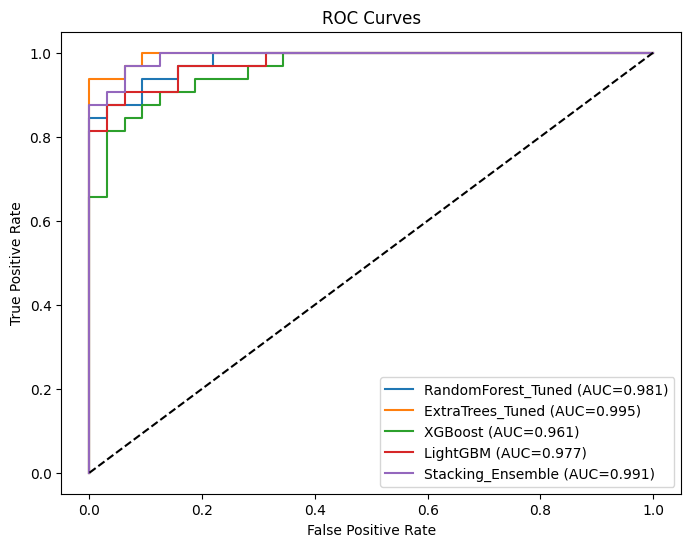

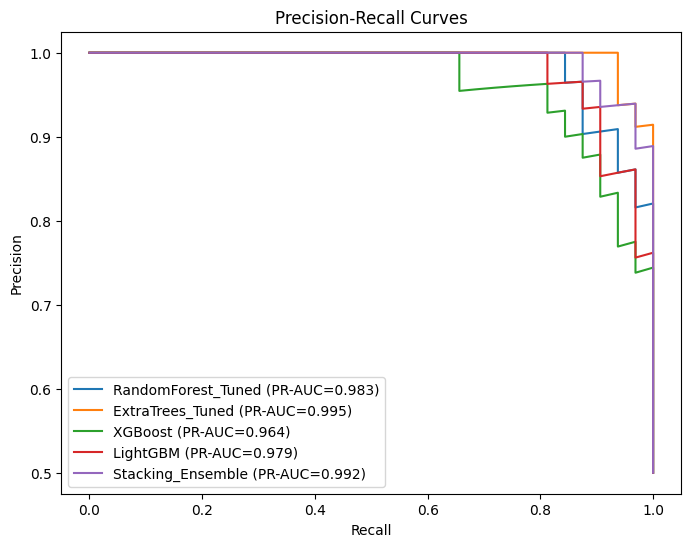

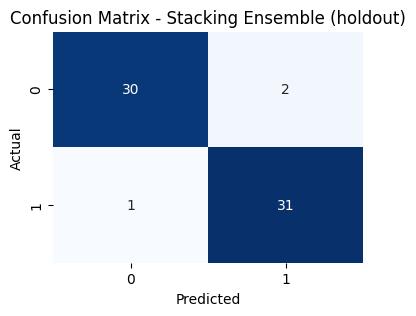

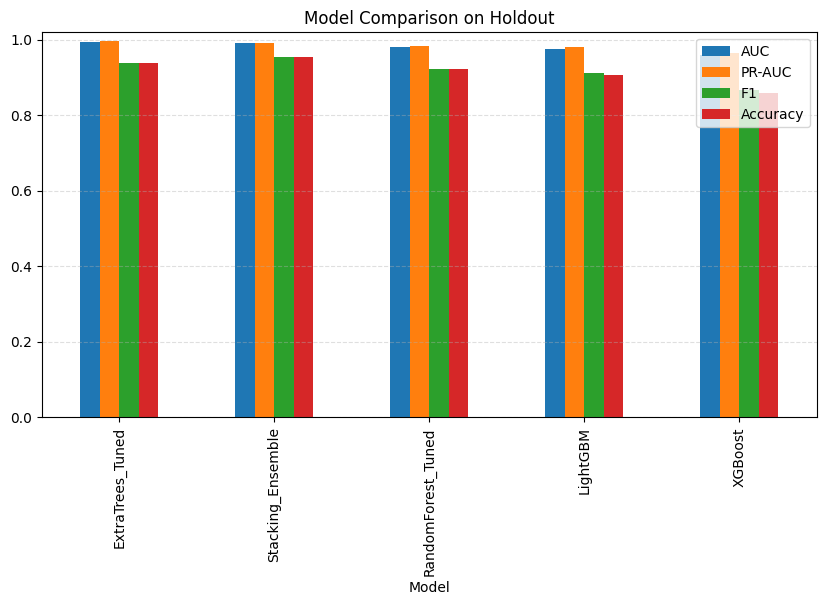

Saved stacking model to: kc3_stacking_model.pkl
Saved results table to: kc3_model_results_holdout.csv


,AUC,PR-AUC,F1,Precision,Recall,MCC,Accuracy,LogLoss
Model,,,,,,,,
ExtraTrees_Tuned,0.9951,0.9954,0.9375,0.9375,0.9375,0.8750,0.9375,0.1866
Stacking_Ensemble,0.9912,0.9916,0.9538,0.9394,0.9688,0.9067,0.9531,0.1835
RandomForest_Tuned,0.9814,0.9833,0.9231,0.9091,0.9375,0.8442,0.9219,0.2408
LightGBM,0.9766,0.9795,0.9118,0.8611,0.9688,0.8189,0.9062,0.2276
XGBoost,0.9609,0.9645,0.8657,0.8286,0.9062,0.7219,0.8594,0.2782


In [6]:
# === KC3 Step 3: Hyperparameter Tuning + Ensembles + Stacking + Evaluation ===
# Assumes X_res, y_res exist (from Step 2)
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, precision_recall_curve, auc, average_precision_score,
                             f1_score, precision_score, recall_score, accuracy_score,
                             confusion_matrix, matthews_corrcoef, log_loss, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ---------------------------
# 1) Holdout split (no leaking)
# ---------------------------
X = X_res.copy()
y = y_res.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ---------------------------
# 2) Hyperparameter tuning: RF and ET (small grids)
# ---------------------------
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(rf, rf_grid, scoring='roc_auc', cv=cv5, n_jobs=-1, verbose=0)
t0 = time.time()
gs_rf.fit(X_train, y_train)
t_rf = time.time() - t0
print("RF best:", gs_rf.best_params_, "CV AUC:", gs_rf.best_score_, "time(s):", round(t_rf,2))
rf_best = gs_rf.best_estimator_

et = ExtraTreesClassifier(random_state=42)
et_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_et = GridSearchCV(et, et_grid, scoring='roc_auc', cv=cv5, n_jobs=-1, verbose=0)
t0 = time.time()
gs_et.fit(X_train, y_train)
t_et = time.time() - t0
print("ET best:", gs_et.best_params_, "CV AUC:", gs_et.best_score_, "time(s):", round(t_et,2))
et_best = gs_et.best_estimator_

# ---------------------------
# 3) XGBoost & LightGBM (quick tuned)
# ---------------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_params = {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4}
xgb.set_params(**xgb_params)
t0 = time.time(); xgb.fit(X_train, y_train); t_xgb = time.time() - t0
print("XGB done time(s):", round(t_xgb,2))

lgb = LGBMClassifier(random_state=42, n_jobs=-1, n_estimators=200, learning_rate=0.05, num_leaves=31)
t0 = time.time(); lgb.fit(X_train, y_train); t_lgb = time.time() - t0
print("LGB done time(s):", round(t_lgb,2))

# ---------------------------
# 4) Build Stacking (use tuned RF, ET, XGB, LGB)
# ---------------------------
estimators = [
    ('rf', rf_best),
    ('et', et_best),
    ('xgb', xgb),
    ('lgb', lgb)
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

t0 = time.time()
stack.fit(X_train, y_train)
t_stack = time.time() - t0
print("Stacking trained in (s):", round(t_stack,2))

# ---------------------------
# 5) Evaluation function
# ---------------------------
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        # fallback to decision_function
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-12)

    fpr_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        'Model': name,
        'AUC': fpr_auc,
        'PR-AUC': pr_auc,
        'F1': f1,
        'Precision': prec,
        'Recall': rec,
        'MCC': mcc,
        'Accuracy': acc,
        'LogLoss': ll,
        'ConfusionMatrix': cm
    }
    return metrics, y_prob, y_pred

# Evaluate all models on holdout
models = {
    'RandomForest_Tuned': rf_best,
    'ExtraTrees_Tuned': et_best,
    'XGBoost': xgb,
    'LightGBM': lgb,
    'Stacking_Ensemble': stack
}

results = []
probs = {}
preds = {}

for name, mod in models.items():
    res, y_prob, y_pred = evaluate_model(name, mod, X_test, y_test)
    results.append(res)
    probs[name] = y_prob
    preds[name] = y_pred
    print(f"\n--- {name} ---")
    print(f"AUC: {res['AUC']:.4f}  PR-AUC: {res['PR-AUC']:.4f}  F1: {res['F1']:.4f}  Precision: {res['Precision']:.4f}  Recall: {res['Recall']:.4f}  MCC: {res['MCC']:.4f}  Acc: {res['Accuracy']:.4f}  LogLoss: {res['LogLoss']:.4f}")
    print("Confusion matrix:\n", res['ConfusionMatrix'])
    print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame([ {k:v for k,v in r.items() if k!='ConfusionMatrix'} for r in results ])
results_df = results_df.set_index('Model').sort_values('AUC', ascending=False)
display(results_df)

# ---------------------------
# 6) Plots: ROC, PR, Confusion Matrix (for stacking), Comparison Bar Chart
# ---------------------------
plt.figure(figsize=(8,6))
for name in models.keys():
    y_prob = probs[name]
    fpr_vals = None
    try:
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,y_prob):.3f})")
    except Exception:
        pass
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(8,6))
for name in models.keys():
    y_prob = probs[name]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc_val = auc(rec, prec)
    plt.plot(rec, prec, label=f"{name} (PR-AUC={pr_auc_val:.3f})")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.show()

# Confusion heatmap for stacking
cm = results_df = next(r for r in results if r['Model']=='Stacking_Ensemble')['ConfusionMatrix']
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Stacking Ensemble (holdout)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Comparison bar chart (AUC, PR-AUC, F1)
metrics_to_plot = ['AUC','PR-AUC','F1','Accuracy']
comp = pd.DataFrame(results).set_index('Model')[metrics_to_plot].sort_values('AUC', ascending=False)
comp.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison on Holdout")
plt.ylim(0,1.02)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# ---------------------------
# 7) Save the final stacking model (pickle)
# ---------------------------
out_path = "kc3_stacking_model.pkl"
with open(out_path, "wb") as f:
    pickle.dump(stack, f)
print("Saved stacking model to:", out_path)

# ---------------------------
# 8) Final results table for writing to paper
# ---------------------------
final_table = pd.DataFrame(results).drop(columns=['ConfusionMatrix']).set_index('Model').round(4).sort_values('AUC', ascending=False)
final_table.to_csv("kc3_model_results_holdout.csv")
print("Saved results table to: kc3_model_results_holdout.csv")
display(final_table)


<Figure size 1000x600 with 0 Axes>

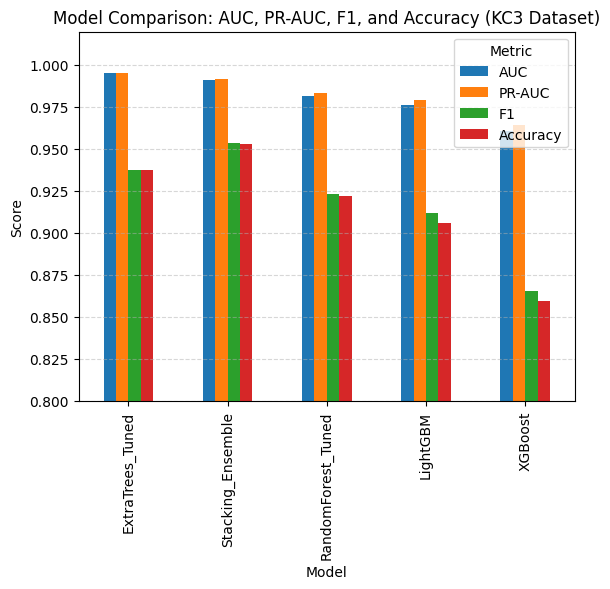

/tmp/ipython-input-2353478665.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis')


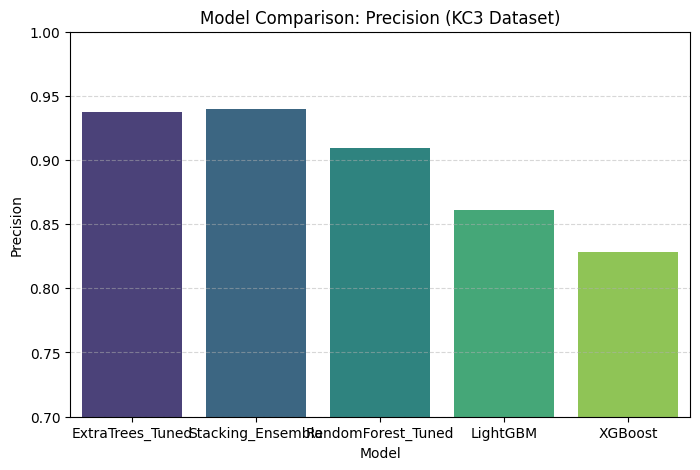

/tmp/ipython-input-2353478665.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis')


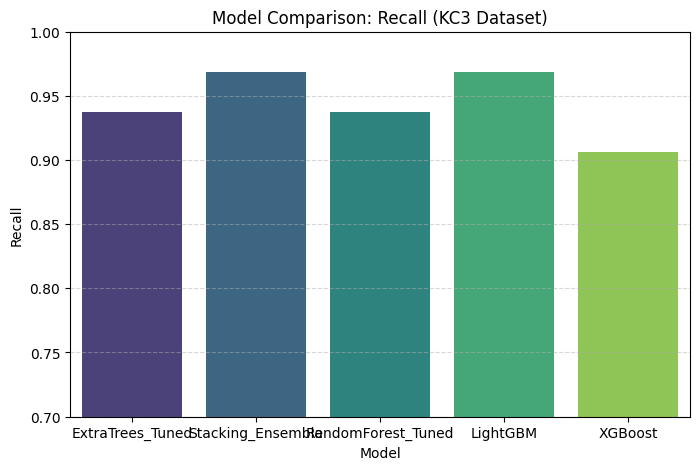

/tmp/ipython-input-2353478665.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis')


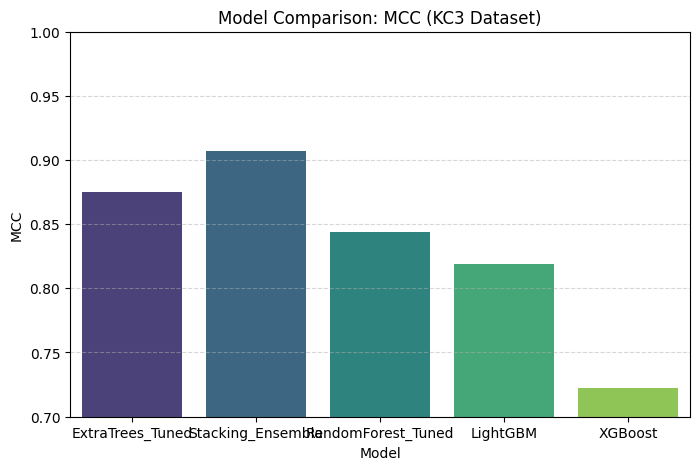

/tmp/ipython-input-2353478665.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis')


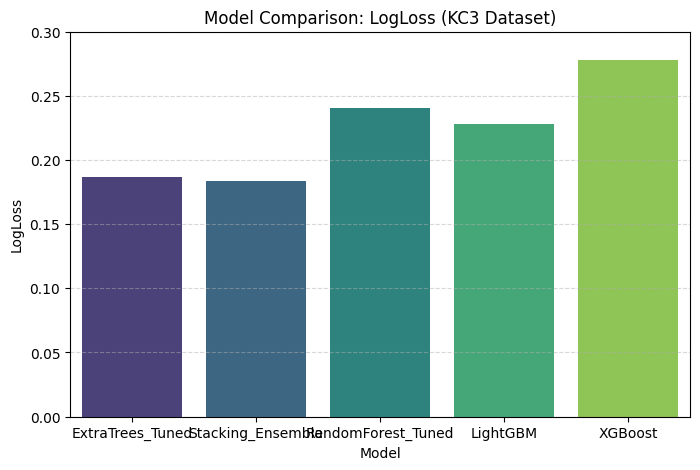

In [7]:
# === KC3 Model Comparison Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# KC3 final model performance table
results_data = {
    'Model': ['ExtraTrees_Tuned', 'Stacking_Ensemble', 'RandomForest_Tuned', 'LightGBM', 'XGBoost'],
    'AUC': [0.9951, 0.9912, 0.9814, 0.9766, 0.9609],
    'PR-AUC': [0.9954, 0.9916, 0.9833, 0.9795, 0.9645],
    'F1': [0.9375, 0.9538, 0.9231, 0.9118, 0.8657],
    'Precision': [0.9375, 0.9394, 0.9091, 0.8611, 0.8286],
    'Recall': [0.9375, 0.9688, 0.9375, 0.9688, 0.9062],
    'MCC': [0.8750, 0.9067, 0.8442, 0.8189, 0.7219],
    'Accuracy': [0.9375, 0.9531, 0.9219, 0.9062, 0.8594],
    'LogLoss': [0.1866, 0.1835, 0.2408, 0.2276, 0.2782]
}

df_results = pd.DataFrame(results_data)
df_results.set_index('Model', inplace=True)

# === 1. Combined chart for AUC, PR-AUC, F1, Accuracy ===
metrics_to_plot = ['AUC', 'PR-AUC', 'F1', 'Accuracy']
df_results_plot = df_results[metrics_to_plot].sort_values('AUC', ascending=False)

plt.figure(figsize=(10, 6))
df_results_plot.plot(kind='bar')
plt.title('Model Comparison: AUC, PR-AUC, F1, and Accuracy (KC3 Dataset)')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Metric')
plt.show()

# === 2. Individual metric comparisons ===
comparison_metrics = ['Precision', 'Recall', 'MCC', 'LogLoss']

for metric in comparison_metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=df_results.index, y=df_results[metric], palette='viridis')
    plt.title(f'Model Comparison: {metric} (KC3 Dataset)')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    if metric != 'LogLoss':
        plt.ylim(0.7, 1.0)
    else:
        plt.ylim(0.0, 0.3)
    plt.show()
